In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [3]:
df=pd.read_csv("Naive-Bayes-Classification-Data.csv")

In [4]:
df.head()

,glucose,bloodpressure,diabetes
0,40,85,0
1,40,92,0
2,45,63,1
3,45,80,0
4,40,73,1


In [5]:
df.columns

Index(['glucose', 'bloodpressure', 'diabetes'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   glucose        995 non-null    int64
 1   bloodpressure  995 non-null    int64
 2   diabetes       995 non-null    int64
dtypes: int64(3)
memory usage: 23.4 KB


In [7]:
df.describe()

,glucose,bloodpressure,diabetes
count,995.000000,995.000000,995.000000
mean,44.306533,79.184925,0.500503
std,6.707567,9.340204,0.500251
min,20.000000,50.000000,0.000000
25%,40.000000,72.000000,0.000000
50%,45.000000,80.000000,1.000000
75%,50.000000,87.000000,1.000000
max,70.000000,100.000000,1.000000


In [8]:
df.isnull().sum()

glucose          0
bloodpressure    0
diabetes         0
dtype: int64

In [15]:
A=df[["glucose","bloodpressure","diabetes"]]
ss=StandardScaler()
ss.fit_transform(A)

array([[-0.64236381,  0.62289857, -1.00100553],
       [-0.64236381,  1.37272377, -1.00100553],
       [ 0.10343781, -1.73369489,  0.99899548],
       ...,
       [-0.64236381,  0.4086628 , -1.00100553],
       [-0.64236381, -2.05504854,  0.99899548],
       [ 0.10343781,  0.30154492, -1.00100553]])

In [9]:
X=df[["glucose","bloodpressure"]]
y=df["diabetes"]

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
model=GaussianNB()
model.fit(X_train,y_train)

GaussianNB()

In [16]:
y_pred=model.predict(X_test)

In [18]:
print("Accuracy: ",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy:  0.9296482412060302
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        93
           1       0.93      0.93      0.93       106

    accuracy                           0.93       199
   macro avg       0.93      0.93      0.93       199
weighted avg       0.93      0.93      0.93       199



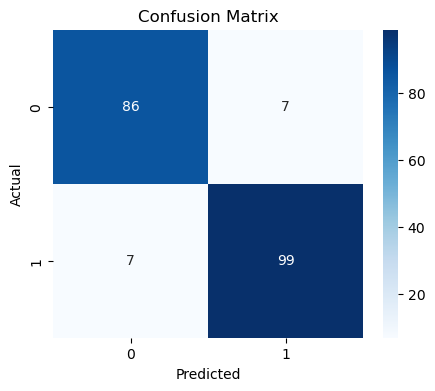

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

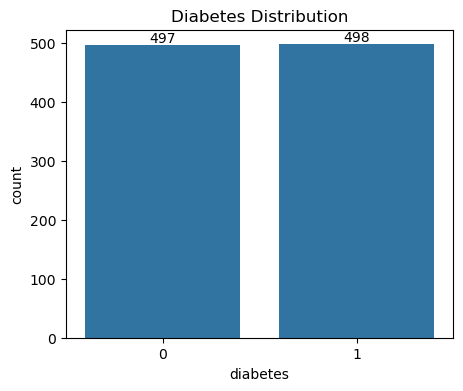

In [20]:
plt.figure(figsize=(5,4))

ax = sns.countplot(x='diabetes', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Diabetes Distribution")

plt.show()